# Exercise

You’re a meteorologist in Washington, DC trying to measure the daily temperature. Based on past experience, you know that the daily temperature will naturally fluctuate around 20° C with a 3° C standard deviation. Unfortunately, your thermometer is lousy and has a 5° C measurement error. Let's simulate this situation and see how a Frequentist and Bayesian approach handle the statistical inference.

In the Frequentist view, we do not rely on prior information and instead make inferences that are accurate in the limit of many random realizations. In particular, in the Frequentist view, the estimate $T_\mathrm{freq}$ of the true temperature $T_\mathrm{true}$ is simply the measured temperature $T_\mathrm{obs}$. The associated confidence interval, denoting the range that contains the true temperature 68% of the time, is $T_\mathrm{freq} \pm $ 5° C, i.e., the measurement error.

On the other hand, a Bayesian statistician will take into account prior information, i.e., in the absence of information, they expect $T_\mathrm{true}$ to follow a normal distribution with mean $T_\mathrm{mean} =$ 20° C  and a standard deviation of 3° C. The estimate with the highest posterior probability is $T_\mathrm{bays} = (T_\mathrm{obs} / 5^2 + T_\mathrm{mean} / 3^2) / (5^{-2} + 3^{-2})$. The associated credible interval, which contains the true value 68% of the time, is $T_\mathrm{bays} \pm $ 2.57° C.

(a) Simulate the above scenario, i.e., repeatedly draw random true temperatures and then simulate the measurement process. Perform a large number of random draws. Whose predictions are right, i.e., the estimates contain the true answer within the given interval 68% of the time?

(b) Let's say our prior assumption is wrong. The daily temperature actually fluctuates around 25° C with a 3° C standard deviation. Assuming we don't know that and erroneously assume a 20° C mean, how does your answer change compared to (a)?

Frequentist Fraction: 68%
Bayesian Fraction: 68%


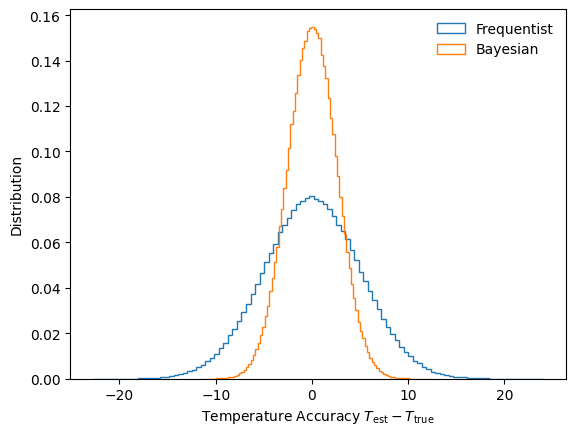

In [1]:
import matplotlib.pyplot as plt
import numpy as np
true_std = 3
obs_std = 5
true_mean = 20
t_true = np.random.normal(true_mean, true_std, size=1000000)
t_obs = np.random.normal(t_true, obs_std)
t_freq = t_obs
t_bays = (t_obs / obs_std**2 + true_mean / true_std**2) / (1 / obs_std**2 + 1 / true_std**2)

plt.hist(t_freq - t_true, bins=100, density=True, histtype='step',
         label='Frequentist')
print(f'Frequentist Fraction: {np.mean(np.abs(t_freq - t_true) < 5.0):.0%}')
plt.hist(t_bays - t_true, bins=100, density=True, histtype='step',
        label='Bayesian')
print(f'Bayesian Fraction: {np.mean(np.abs(t_bays - t_true) < 2.57):.0%}')
plt.xlabel(r'Temperature Accuracy $T_\mathrm{est} - T_\mathrm{true}$')
plt.legend(loc='best', frameon=False)
plt.ylabel('Distribution');

Frequentist Fraction: 68%
Bayesian Fraction: 33%


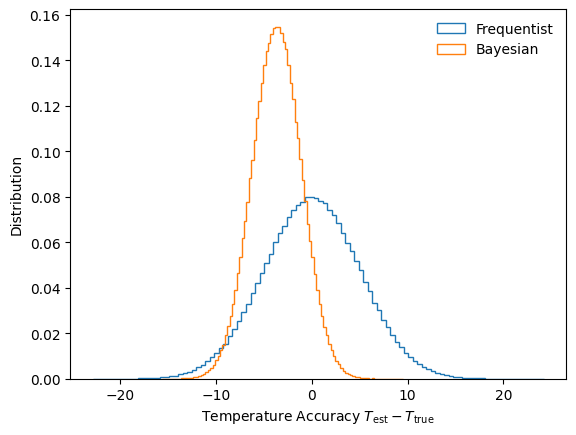

In [4]:
import matplotlib.pyplot as plt
import numpy as np
true_mean = 25
obs_mean = 20
true_std = 3
obs_std = 5
t_true = np.random.normal(true_mean, true_std, size=1000000)
t_obs = np.random.normal(t_true, obs_std)
t_freq = t_obs
t_bays = (t_obs / obs_std**2 + obs_mean / true_std**2) / (1 / obs_std**2 + 1 / true_std**2)

plt.hist(t_freq - t_true, bins=100, density=True, histtype='step',
         label='Frequentist')
print(f'Frequentist Fraction: {np.mean(np.abs(t_freq - t_true) < 5.0):.0%}')
plt.hist(t_bays - t_true, bins=100, density=True, histtype='step',
        label='Bayesian')
print(f'Bayesian Fraction: {np.mean(np.abs(t_bays - t_true) < 2.57):.0%}')
plt.xlabel(r'Temperature Accuracy $T_\mathrm{est} - T_\mathrm{true}$')
plt.legend(loc='best', frameon=False)
plt.ylabel('Distribution');